In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

def fetch_nasa_weather_data(lat, lon, start_date, end_date, output_filename="weather_data.csv"):
    url = "https://power.larc.nasa.gov/api/temporal/daily/point"
    
    params = {
        "parameters": "T2M,PRECTOTCORR,RH2M,WS10M", 
        "community": "AG",         
        "longitude": lon,
        "latitude": lat,
        "start": start_date,       
        "end": end_date,           
        "format": "JSON"
    }

    print(f"Fetching data for Lat: {lat}, Lon: {lon}...")
    response = requests.get(url, params=params)
    
    if response.status_code != 200:
        print(f"Error fetching data: HTTP {response.status_code}")
        return None
        
    data = response.json()
    weather_dict = data['properties']['parameter']
    
    df = pd.DataFrame(weather_dict)
    df.index = pd.to_datetime(df.index, format="%Y%m%d")
    df.index.name = 'Date'
    
    df = df.rename(columns={
        "T2M": "Temperature_C",
        "PRECTOTCORR": "Rainfall_mm",
        "RH2M": "Humidity_pct",
        "WS10M": "WindSpeed_m_s"
    })
    
    df = df.replace(-999.0, pd.NA)
    df.to_csv(output_filename)
    
    print(f"Success! Data saved to '{output_filename}'")
    return df

In [2]:
# Replace with your district's coordinates
district_latitude = 28.61   
district_longitude = 77.23

# Fetching 8 years of data
weather_df = fetch_nasa_weather_data(
    lat=district_latitude, 
    lon=district_longitude, 
    start_date="20150101", 
    end_date="20231231",
    output_filename="District_Weather_2015_2023.csv"
)

# Display the first 5 rows in Jupyter's rich format
weather_df.head()

Fetching data for Lat: 28.61, Lon: 77.23...
Success! Data saved to 'District_Weather_2015_2023.csv'


,Temperature_C,Rainfall_mm,Humidity_pct,WindSpeed_m_s
Date,,,,
2015-01-01,15.08,0.02,44.51,2.13
2015-01-02,15.76,3.90,59.67,1.87
2015-01-03,14.41,10.12,76.62,1.70
2015-01-04,13.53,0.00,62.98,3.58
2015-01-05,13.07,0.00,44.10,5.79


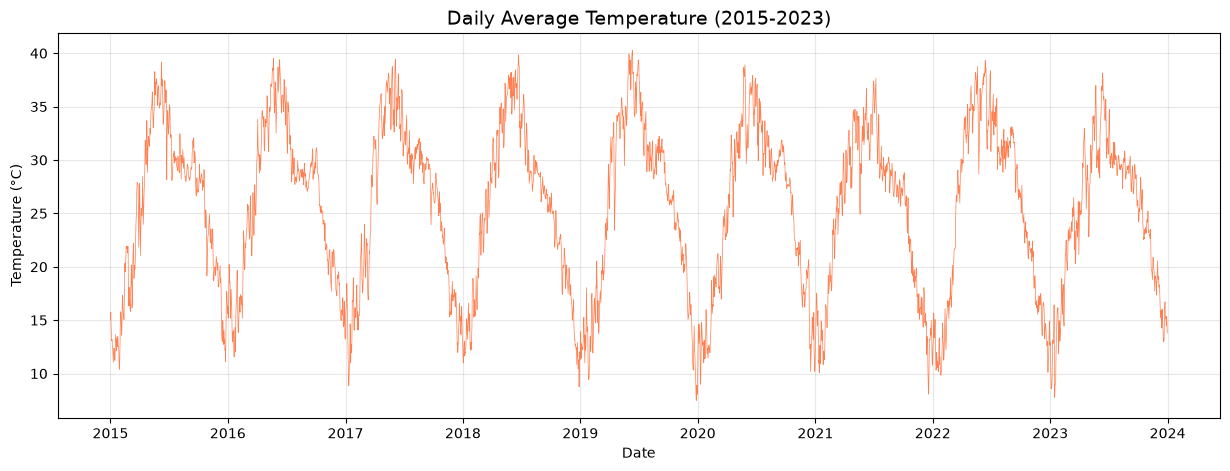

In [3]:
# Set the figure size to fit nicely in the notebook
plt.figure(figsize=(15, 5))

# Plot the temperature data
plt.plot(weather_df.index, weather_df['Temperature_C'], color='coral', linewidth=0.5)

# Add titles and labels
plt.title('Daily Average Temperature (2015-2023)', fontsize=14)
plt.ylabel('Temperature (°C)')
plt.xlabel('Date')
plt.grid(True, alpha=0.3)

# Display the plot
plt.show()

In [4]:
from statsmodels.tsa.stattools import adfuller

# 1. Select the column you want to test (e.g., Temperature)
# We must drop NaN values, otherwise the ADF test will fail
series_to_test = weather_df['Temperature_C'].dropna()

# 2. Run the ADF test
print("Running Augmented Dickey-Fuller Test on Temperature...\n")
adf_result = adfuller(series_to_test)

# 3. Format and print the results clearly
print("--- ADF Test Results ---")
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"  {key}: {value:.4f}")

print("\n--- Conclusion ---")
# 4. Interpret the p-value
if adf_result[1] <= 0.05:
    print("Result: Strong evidence against the null hypothesis (p <= 0.05).")
    print("Verdict: The data is STATIONARY. You can proceed with ARIMA modeling (d=0).")
else:
    print("Result: Weak evidence against the null hypothesis (p > 0.05).")
    print("Verdict: The data is NON-STATIONARY. You must difference the data before modeling (d > 0).")

Running Augmented Dickey-Fuller Test on Temperature...

--- ADF Test Results ---
ADF Statistic: -4.3340
p-value: 0.0004
Critical Values:
  1%: -3.4324
  5%: -2.8624
  10%: -2.5672

--- Conclusion ---
Result: Strong evidence against the null hypothesis (p <= 0.05).
Verdict: The data is STATIONARY. You can proceed with ARIMA modeling (d=0).


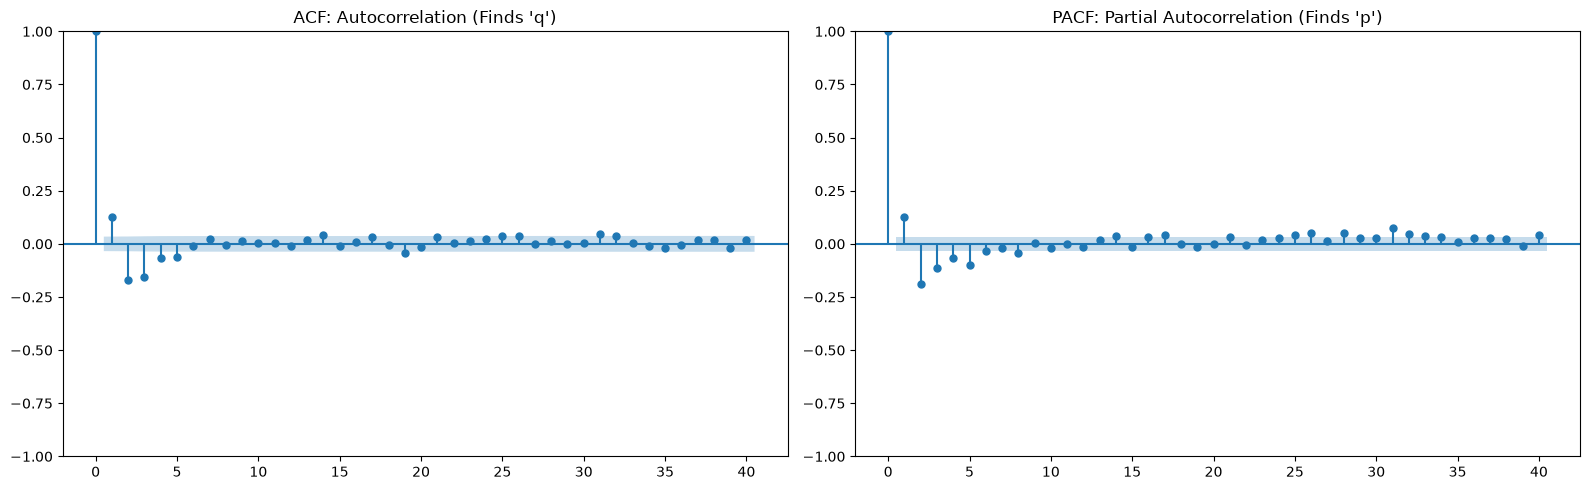

In [5]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# 1. Define diff_series right here so Jupyter never loses it
weather_df['Temp_Diff'] = weather_df['Temperature_C'].diff(periods=1)
diff_series = weather_df['Temp_Diff'].dropna()

# 2. Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 3. Plot ACF on the left
# We use lags=40 to look at the correlation over the last 40 days
plot_acf(diff_series, ax=axes[0], lags=40, title="ACF: Autocorrelation (Finds 'q')")

# 4. Plot PACF on the right
plot_pacf(diff_series, ax=axes[1], lags=40, title="PACF: Partial Autocorrelation (Finds 'p')")

# Display the plots
plt.tight_layout()
plt.show()

Training data: 96 months
Testing data: 12 months

Training SARIMA model... (This takes a few seconds)


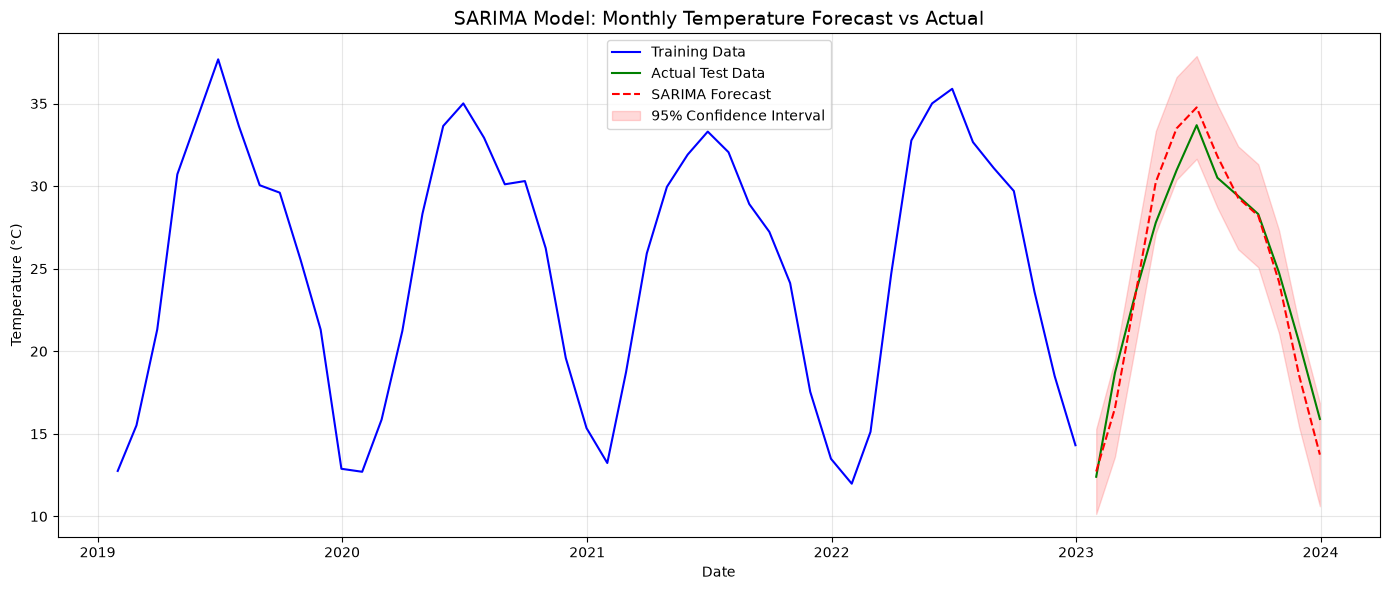

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5304      0.157      3.380      0.001       0.223       0.838
ma.L1         -1.0000    590.784     -0.002      0.999   -1158.916    1156.916
ar.S.L12      -0.0927      0.238     -0.390      0.697      -0.559       0.373
ma.S.L12      -0.6831      0.304     -2.246      0.025      -1.279      -0.087
sigma2         1.6733    988.611      0.002      0.999   -1935.969    1939.316


In [6]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt

# 1. Resample daily data to monthly averages (Avoids the s=365 crash)
# 'ME' stands for Month-End frequency
monthly_temp = weather_df['Temperature_C'].resample('ME').mean()

# 2. Train/Test Split
# We will train on all data EXCEPT the last 12 months, and test our model on that final year.
train = monthly_temp.iloc[:-12]
test = monthly_temp.iloc[-12:]

print(f"Training data: {len(train)} months")
print(f"Testing data: {len(test)} months\n")

# 3. Define and Fit the SARIMA Model
# order = (p, d, q) -> Non-seasonal components
# seasonal_order = (P, D, Q, s) -> Seasonal components (s=12 for monthly)
# We are starting with (1, 1, 1) as a baseline. You can tune these later based on your ACF/PACF.
print("Training SARIMA model... (This takes a few seconds)")
model = SARIMAX(train, 
                order=(1, 1, 1),              
                seasonal_order=(1, 1, 1, 12), 
                enforce_stationarity=False,
                enforce_invertibility=False)

sarima_fit = model.fit(disp=False)

# 4. Generate the Forecast for the next 12 months
forecast = sarima_fit.get_forecast(steps=len(test))
predictions = forecast.predicted_mean
conf_int = forecast.conf_int() # 95% Confidence Intervals

# 5. Plot the Results
plt.figure(figsize=(14, 6))

# Plot the last 4 years of training data just to keep the chart readable
plt.plot(train.index[-48:], train.iloc[-48:], label='Training Data', color='blue')

# Plot the actual testing data
plt.plot(test.index, test, label='Actual Test Data', color='green')

# Plot the model's predictions
plt.plot(predictions.index, predictions, color='red', label='SARIMA Forecast', linestyle='--')

# Add the shaded confidence interval
plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='red', alpha=0.15, label='95% Confidence Interval')

plt.title('SARIMA Model: Monthly Temperature Forecast vs Actual', fontsize=14)
plt.ylabel('Temperature (°C)')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print out the mathematical summary of the model
print(sarima_fit.summary().tables[1])

In [7]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# 1. Calculate RMSE (Square root of the Mean Squared Error)
rmse = np.sqrt(mean_squared_error(test, predictions))

# 2. Calculate MAPE 
# Scikit-learn returns a decimal (e.g., 0.05), so we multiply by 100 to get a percentage
mape = mean_absolute_percentage_error(test, predictions) * 100

# 3. Print the results clearly
print("--- SARIMA Model Accuracy ---")
print(f"RMSE: {rmse:.2f} °C")
print(f"MAPE: {mape:.2f}%")

# 4. Contextualize the results
print("\n--- What this means ---")
print(f"On average, your model's forecast is off by {rmse:.2f} degrees Celsius.")
print(f"Its predictions deviate from the actual temperature by {mape:.2f}%.")

--- SARIMA Model Accuracy ---
RMSE: 1.56 °C
MAPE: 5.43%

--- What this means ---
On average, your model's forecast is off by 1.56 degrees Celsius.
Its predictions deviate from the actual temperature by 5.43%.


Training Random Forest Machine Learning Model...

--- RANDOM FOREST Accuracy ---
RMSE: 6.74 °C
MAPE: 29.07%


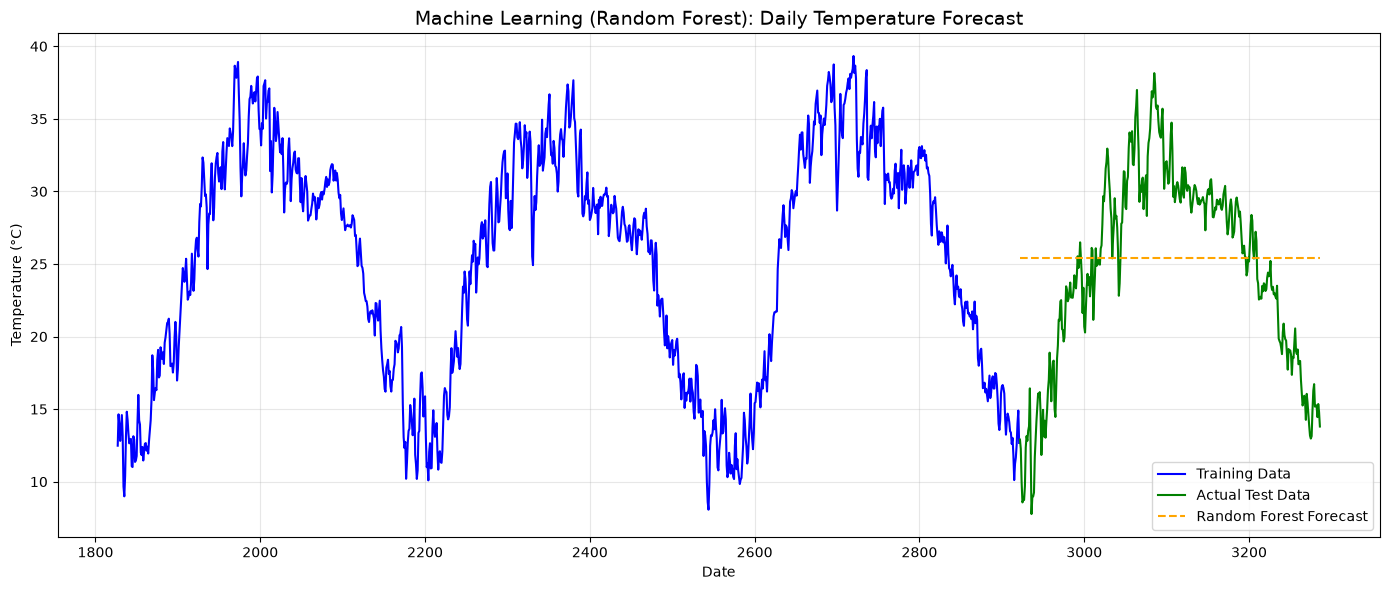

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# 1. Prepare Data for Machine Learning
ml_df = weather_df[['Temperature_C']].dropna().copy()

# THE FIX: Force the index to be recognized as true datetime objects
ml_df['Date'] = pd.to_datetime(ml_df.index)

# Create "Time" features so the algorithm can learn the seasons
ml_df['Month'] = ml_df['Date'].dt.month
ml_df['DayOfYear'] = ml_df['Date'].dt.dayofyear
ml_df['Year'] = ml_df['Date'].dt.year

# 2. Train/Test Split (Reserve the last 365 days)
train_ml = ml_df.iloc[:-365]
test_ml = ml_df.iloc[-365:]

# Define our features (X) and target (y)
features = ['Month', 'DayOfYear', 'Year']
X_train = train_ml[features]
y_train = train_ml['Temperature_C']

X_test = test_ml[features]
y_test = test_ml['Temperature_C']

print("Training Random Forest Machine Learning Model...")

# 3. Initialize and Train the Model
# n_estimators=100 means we are building 100 decision trees and averaging them
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 4. Generate Predictions
rf_predictions = rf_model.predict(X_test)

# Convert predictions back to a Pandas Series with the correct dates for plotting
rf_forecast = pd.Series(rf_predictions, index=test_ml.index)

# 5. Calculate Metrics
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_mape = mean_absolute_percentage_error(y_test, rf_predictions) * 100

print("\n--- RANDOM FOREST Accuracy ---")
print(f"RMSE: {rf_rmse:.2f} °C")
print(f"MAPE: {rf_mape:.2f}%")

# 6. Plot the Results
plt.figure(figsize=(14, 6))

# Plot the last 3 years of training data
plt.plot(train_ml.index[-1095:], train_ml['Temperature_C'].iloc[-1095:], label='Training Data', color='blue')

# Plot actual vs predicted
plt.plot(test_ml.index, test_ml['Temperature_C'], label='Actual Test Data', color='green')
plt.plot(rf_forecast.index, rf_forecast, color='orange', label='Random Forest Forecast', linestyle='--')

plt.title('Machine Learning (Random Forest): Daily Temperature Forecast', fontsize=14)
plt.ylabel('Temperature (°C)')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

--- Final Model Comparison ---


,Forecast Type,RMSE (°C),MAPE (%)
Model,,,
SARIMA,Monthly Average,1.56,5.43
Holt-Winters,Daily Exact,2.66,9.60
Random Forest,Daily Exact,6.74,29.07


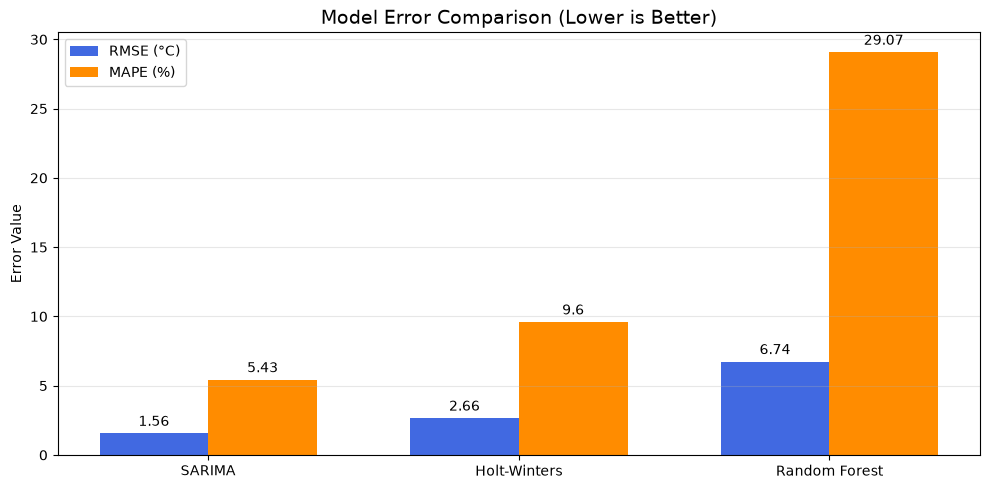

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# THE FIX: Calculate the missing Holt-Winters metrics right here
# ==========================================
hw_rmse = np.sqrt(np.mean((test_hw - hw_forecast)**2))
hw_mape = np.mean(np.abs((test_hw - hw_forecast) / test_hw)) * 100
# ==========================================

# 1. Gather all the metrics from your previous cells
results_data = {
    "Model": ["SARIMA", "Holt-Winters", "Random Forest"],
    "Forecast Type": ["Monthly Average", "Daily Exact", "Daily Exact"],
    "RMSE (°C)": [rmse, hw_rmse, rf_rmse],
    "MAPE (%)": [mape, hw_mape, rf_mape]
}

# 2. Create the Pandas DataFrame
comparison_df = pd.DataFrame(results_data)

# Set the Model column as the index for a cleaner look
comparison_df.set_index("Model", inplace=True)

# Round the numbers to 2 decimal places for a professional appearance
comparison_df = comparison_df.round(2)

# 3. Print the table (Jupyter will render this beautifully)
print("--- Final Model Comparison ---")
display(comparison_df)

# ==========================================
# Plot the comparison as a Bar Chart
# ==========================================
fig, ax1 = plt.subplots(figsize=(10, 5))

# Set up the bar positions
x = np.arange(len(comparison_df.index))
width = 0.35

# Plot RMSE and MAPE side-by-side
rects1 = ax1.bar(x - width/2, comparison_df['RMSE (°C)'], width, label='RMSE (°C)', color='royalblue')
rects2 = ax1.bar(x + width/2, comparison_df['MAPE (%)'], width, label='MAPE (%)', color='darkorange')

# Add labels and formatting
ax1.set_ylabel('Error Value')
ax1.set_title('Model Error Comparison (Lower is Better)', fontsize=14)
ax1.set_xticks(x)
ax1.set_xticklabels(comparison_df.index)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Add the exact numbers on top of the bars
ax1.bar_label(rects1, padding=3)
ax1.bar_label(rects2, padding=3)

plt.tight_layout()
plt.show()

In [19]:
import requests
import pandas as pd

def fetch_kullu_weather_data():
    print("Fetching 8 years of climate data for Kullu from NASA satellites...")
    
    # Kullu, Himachal Pradesh coordinates
    lat = 31.9579
    lon = 77.1095
    
    # NASA POWER API endpoint for daily data
    url = f"https://power.larc.nasa.gov/api/temporal/daily/point"
    
    # We are asking for Temperature, Precipitation, Humidity, and Wind Speed
    params = {
        "parameters": "T2M,PRECTOTCORR,RH2M,WS10M",
        "community": "RE",
        "longitude": lon,
        "latitude": lat,
        "start": "20150101",
        "end": "20231231",
        "format": "JSON"
    }
    
    response = requests.get(url, params=params)
    data = response.json()['properties']['parameter']
    
    # Convert the JSON dictionary into a Pandas DataFrame
    df = pd.DataFrame(data)
    
    # Reset index to turn the dates from row names into a proper column
    df = df.reset_index()
    
    # Rename columns so they match what our Streamlit dashboard expects exactly
    df = df.rename(columns={
        "index": "Date",
        "T2M": "Temperature_C",
        "PRECTOTCORR": "Rainfall_mm",
        "RH2M": "Humidity_pct",
        "WS10M": "WindSpeed_m_s"
    })
    
    # Format the date column properly
    df['Date'] = pd.to_datetime(df['Date'], format='%Y%m%d')
    
    # Drop rows where NASA had missing satellite readings (usually represented by -999)
    df = df[df['Temperature_C'] > -100]
    
    # Save the file to your local computer
    filename = "Kullu_Weather_2015_2023.csv"
    df.to_csv(filename, index=False)
    
    print(f"SUCCESS! Downloaded {len(df)} days of weather data.")
    print(f"Saved as: {filename}")
    
    return df

# Run the function
weather_df = fetch_kullu_weather_data()
display(weather_df.head())

Fetching 8 years of climate data for Kullu from NASA satellites...
SUCCESS! Downloaded 3287 days of weather data.
Saved as: Kullu_Weather_2015_2023.csv


,Date,Temperature_C,Rainfall_mm,Humidity_pct,WindSpeed_m_s
0,2015-01-01,4.86,0.00,46.17,1.78
1,2015-01-02,3.53,1.00,62.77,2.15
2,2015-01-03,2.52,5.67,77.17,1.37
3,2015-01-04,1.38,0.30,67.08,1.89
4,2015-01-05,4.18,0.00,42.31,1.62
